In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("phileinsophos/predict-loan-amount-data")

print("Path to dataset files:", path)
# path = "/kaggle/input/predict-loan-amount-data"

Path to dataset files: /kaggle/input/predict-loan-amount-data


# CONFIGURATIONS

In [ ]:
DATASET_PATH = path
TRAIN_FILE = "train.csv"
TEST_FILE = "test.csv"

# Target variable
TARGET_COL = "Loan Sanction Amount (USD)"

# Columns to drop
UNNECESSARY_COLS = ['Customer ID', 'Name', 'Property ID']

# Categorical filling strategy
CATEGORICAL_FILL_MODE = "mode"

# Numerical fill defaults
NUMERIC_FILL_VALUES = {
    'Credit Score': 'median',
    'Property Age': 'median',
    'Income (USD)': 'median',
    'Loan Amount Request (USD)': 'median',
    'Current Loan Expenses (USD)': 0,
    'No. of Defaults': 0,
    'Dependents': 0
}

# Outlier threshold
OUTLIER_FILTER = {
    'Income (USD)': 1000000
}

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.svm import SVR

option = int(input(
    "Choose the regression model:\n"
    "1. Linear Regression\n"
    "2. Support Vector Regressor (SVR)\n"
    "3. Lasso Regression\n"
    "4. Ridge Regression\n"
))

model_param_map = {
    1: {
        "model": LinearRegression(),
        "params": {
            "copy_X": [True, False],
            "fit_intercept": [True, False],
            "positive": [True, False]
        }
    },
    2: {
        "model": SVR(),
        "params": [
            {"kernel": ["linear", "poly", "rbf", "sigmoid"]}
            # {"kernel": ["linear"], "C": [1, 10]},

            # {"kernel": ["poly"], "C": [1, 10],
            #  "degree": [2, 3], "gamma": ["scale", "auto"]},

            # {"kernel": ["rbf"], "C": [1, 10],
            #  "gamma": ["scale", 0.1, 1]},

            # {"kernel": ["sigmoid"], "C": [1, 10],
            #  "gamma": ["scale", 0.1, 1]}
        ]
    },
    3: {
        "model": Lasso(random_state=42, max_iter=10000),
        "params": {
            "alpha": [0.01, 0.1, 1, 10, 100],
            "fit_intercept": [True, False],
            "positive": [True, False],
            "selection": ["cyclic", "random"]
        }
    },
    4: {
        "model": Ridge(random_state=42, max_iter=10000),
        "params": {
            "alpha": [0.01, 0.1, 1, 10, 100],
            "fit_intercept": [True, False],
            "positive": [True, False]
        }
    }
}

model_config = model_param_map[option]
base_model = model_config["model"]
param_grid = model_config["params"]

Choose the regression model:
1. Linear Regression
2. Support Vector Regressor (SVR)
3. Lasso Regression
4. Ridge Regression
2


# IMPORT FUNCTIONS

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

# LOAD DATA

In [ ]:
df = pd.read_csv(f"{DATASET_PATH}/{TRAIN_FILE}")
print("Shape:", df.shape)

Shape: (30000, 24)


# REMOVE UNWANTED COLUMNS

In [ ]:
if UNNECESSARY_COLS:
    df.drop(columns=[col for col in UNNECESSARY_COLS if col in df.columns], inplace=True)

# FILL MISSING VALUES

In [ ]:
for col, val in NUMERIC_FILL_VALUES.items():
    if col in df.columns:
        if val == 'median':
            df[col] = df[col].fillna(df[col].median())
        elif val == 'mean':
            df[col] = df[col].fillna(df[col].mean())
        else:
            df[col] = df[col].fillna(val)

for col in df.select_dtypes(include='object').columns:
    if CATEGORICAL_FILL_MODE == "mode":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna("Unknown")

df = df[~df[TARGET_COL].isna()]
# df = df[df['Loan Sanction Amount (USD)'] > 0]

# CHECK AND REMOVE OUTLIERS

In [ ]:
# for col in df.select_dtypes(include=['int64', 'float64']).columns:
#     sns.histplot(df[col], kde=True)
#     plt.title(f"Distribution of {col}")
#     plt.show()

In [ ]:
for col, threshold in OUTLIER_FILTER.items():
    df = df[df[col] < threshold]

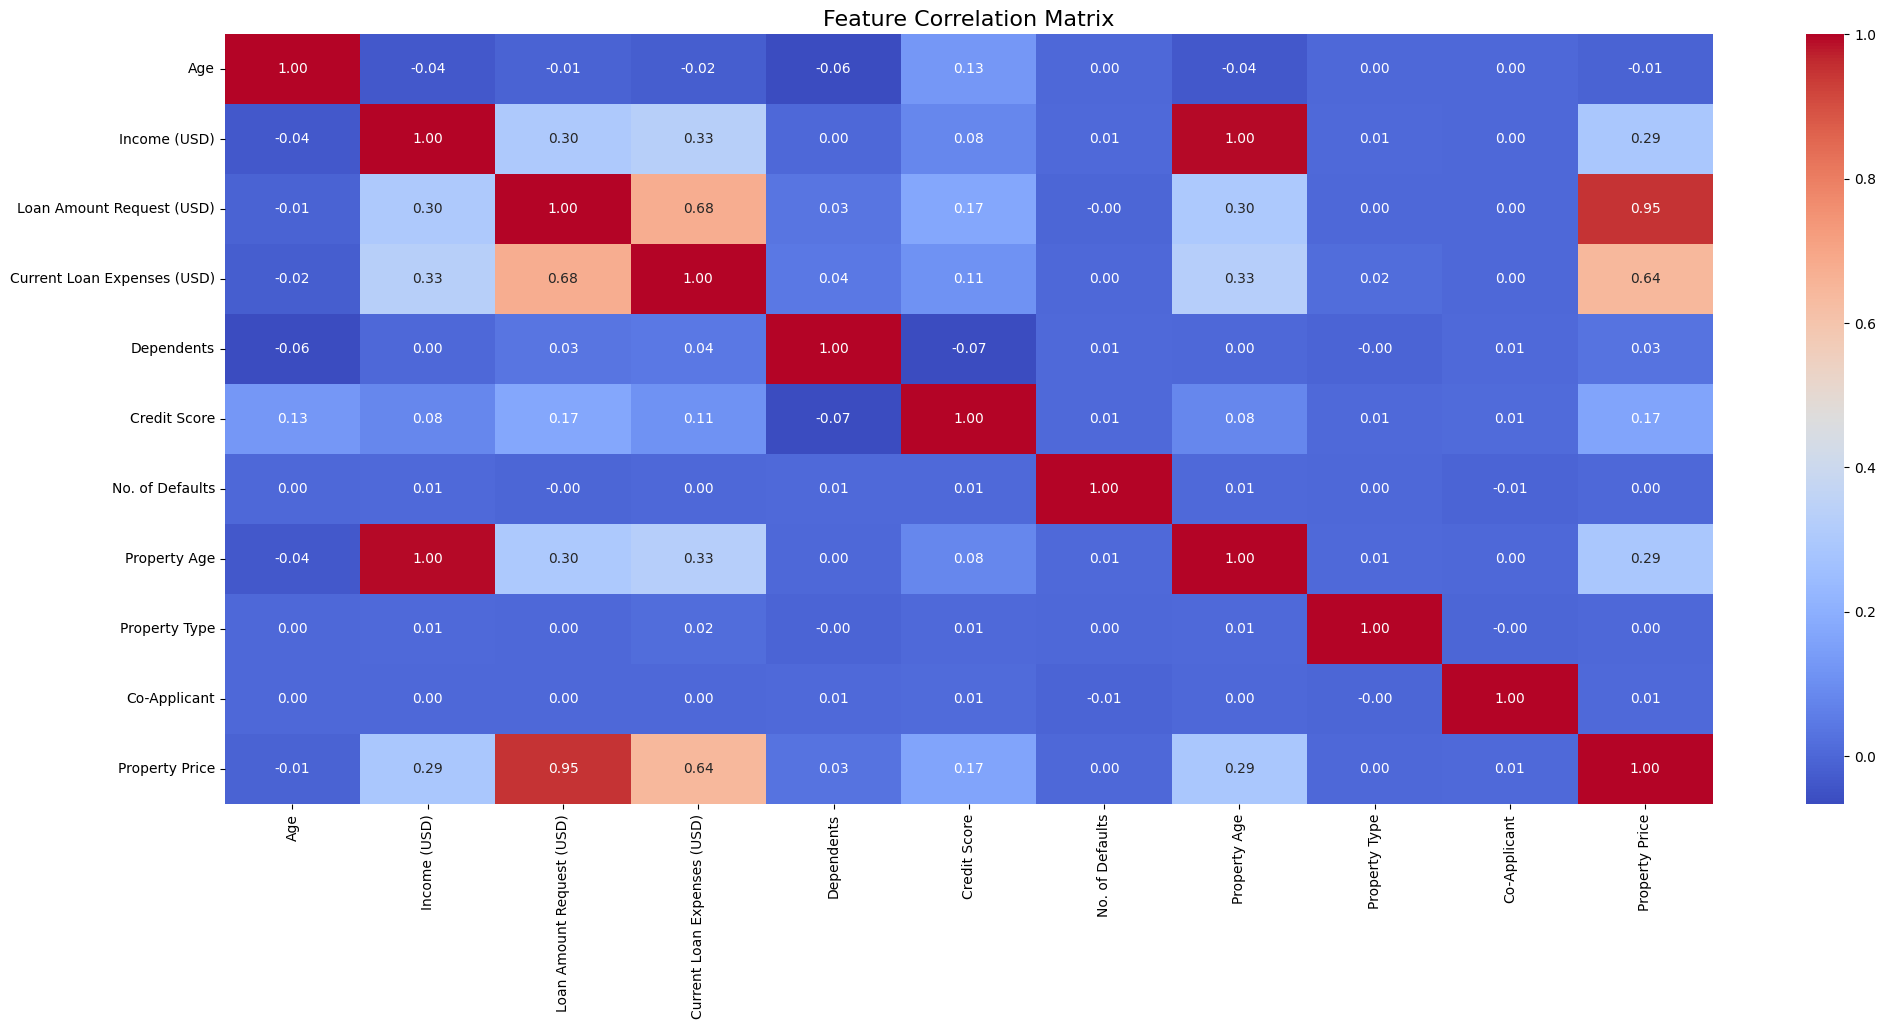

In [ ]:
non_numerical_cols = df.select_dtypes(include=['object']).columns.tolist()
corr = df.drop(columns=[TARGET_COL] + non_numerical_cols).corr()

# Plot heatmap
plt.figure(figsize=(24, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Feature Correlation Matrix", fontsize=16)
plt.show()

# ENCODE CATEGORICAL DATA

In [ ]:
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# STANDARDIZE CONTINUOUS DATA

In [ ]:
# scaler = StandardScaler()
# numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# features_to_scale = [col for col in numerical_cols if col != TARGET_COL]
# df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# SPLITTING TO FEATURES AND TARGETS

In [ ]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Validation

In [ ]:
# Adjusted R² function
def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

# Step 1: Split into Train, Validation, Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
numerical_cols = X_temp.select_dtypes(include=['int64', 'float64']).columns.tolist()
X_temp[numerical_cols] = scaler.fit_transform(X_temp[numerical_cols])

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 0.25 x 0.8 = 0.2

# CROSS VALIDATION

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(estimator=base_model,
                    param_grid=param_grid,
                    scoring="r2",
                    cv=kf,
                    n_jobs=-1,
                    verbose=3)
grid.fit(X_val, y_val)

print("✅ Best hyperparameters:", grid.best_params_)

best_model = grid.best_estimator_

metrics = {
    "Fold": [], "MAE": [], "MSE": [], "RMSE": [], "R2": [], "AdjR2": []
}

fold = 1
for train_idx, val_idx in kf.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    best_model.fit(X_train_fold, y_train_fold)
    y_pred = best_model.predict(X_val_fold)

    r2_test = r2_score(y_val_fold, y_pred)
    metrics["Fold"].append(f"Fold {fold}")
    metrics["MAE"].append(mean_absolute_error(y_val_fold, y_pred))
    metrics["MSE"].append(mean_squared_error(y_val_fold, y_pred))
    metrics["RMSE"].append(np.sqrt(metrics["MSE"][-1]))
    metrics["R2"].append(r2_test)
    metrics["AdjR2"].append(adjusted_r2(r2_test, len(y_val_fold), X_val_fold.shape[1]))

    fold += 1

# Add average
metrics["Fold"].append("Average")
for key in list(metrics.keys())[1:]:
    metrics[key].append(np.mean(metrics[key]))

metrics_df = pd.DataFrame(metrics)
metrics_df

Fitting 5 folds for each of 4 candidates, totalling 20 fits
✅ Best hyperparameters: {'kernel': 'linear'}


,Fold,MAE,MSE,RMSE,R2,AdjR2
0,Fold 1,32241.626442,1.762010e+09,41976.306937,0.261796,0.254611
1,Fold 2,31527.656008,1.652722e+09,40653.680483,0.271198,0.264105
2,Fold 3,31508.079168,1.687315e+09,41076.938832,0.261763,0.254578
3,Fold 4,32553.193238,1.804065e+09,42474.280770,0.278881,0.271862
4,Fold 5,30012.621603,1.530508e+09,39121.712651,0.271877,0.264791
5,Average,31568.635292,1.687324e+09,41060.583935,0.269103,0.261990


In [ ]:
results = pd.DataFrame(grid.cv_results_)

metrics_table = results[
    ["params", "mean_test_score", "std_test_score"]
]

metrics_table

,params,mean_test_score,std_test_score
0,{'kernel': 'linear'},0.267226,0.008149
1,{'kernel': 'poly'},-0.067687,0.007964
2,{'kernel': 'rbf'},-0.068376,0.009512
3,{'kernel': 'sigmoid'},-0.054069,0.009457


In [ ]:
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [ ]:
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

sets = {
    "Train": (X_train, y_train),
    "Validation": (X_val, y_val),
    "Test": (X_test, y_test)
}

for name, (X, y) in sets.items():
    y_pred = best_model.predict(X)
    r2 = r2_score(y, y_pred)
    adj_r2 = adjusted_r2(r2, len(y), X.shape[1])

    print(f"\n📊 {name} Metrics:")
    print(f"  MAE     : {mean_absolute_error(y, y_pred):.4f}")
    print(f"  MSE     : {mean_squared_error(y, y_pred):.4f}")
    print(f"  RMSE    : {np.sqrt(mean_squared_error(y, y_pred)):.4f}")
    print(f"  R²      : {r2:.4f}")
    print(f"  Adj R²  : {adj_r2:.4f}")


📊 Train Metrics:
  MAE     : 30281.3006
  MSE     : 1555886081.2099
  RMSE    : 39444.7218
  R²      : 0.3265
  Adj R²  : 0.3252

📊 Validation Metrics:
  MAE     : 30733.4705
  MSE     : 1608579977.4940
  RMSE    : 40107.1063
  R²      : 0.3272
  Adj R²  : 0.3259

📊 Test Metrics:
  MAE     : 29976.3839
  MSE     : 1530838475.4915
  RMSE    : 39125.9310
  R²      : 0.3245
  Adj R²  : 0.3230
